# Cluster Analysis 

1. Load project data                 
2. Construct text for cases/questions
3. Generate E5 embeddings
4. Prepare a clustering representation
5. Cluster the original embeddings
6. Generate PaCMAP projection
7. Overlay cluster assignments on PaCMAP
8. Examine what the clusters contain
9. Compare clusters with CAP / ODA metadata

## 1. Load Project Data

In [1]:
import sys
from pathlib import Path
import pandas as pd

In [2]:
PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.project_data_ANEY import load_project_data

data = load_project_data()

df_candidate_tests = data["candidate_tests"]
df_questions = data["questions"]

df_roll_calls = data["roll_calls"]
df_cases = data["cases"]
df_votes = data["votes"]
df_politicians = data["politicians"]
df_actor_candidate_map = data["actor_candidate_map"]

df_cap_bills = data["cap_bills"]


print("Candidate questions:", df_questions.shape)
print("Roll calls:", df_roll_calls.shape)
print("Cases:", df_cases.shape)
print("Votes:", df_votes.shape)
print("Politicians:", df_politicians.shape)
print("Actor-candidate map:", df_actor_candidate_map.shape)
print("CAP bills:", df_cap_bills.shape)

Candidate questions: (136, 2)
Roll calls: (2128, 12)
Cases: (2128, 6)
Votes: (363623, 4)
Politicians: (3402, 5)
Actor-candidate map: (1021, 6)
CAP bills: (15101, 37)


## 2. Construct text for cases/questions

In [3]:
df_cases["text"] = (
    df_cases["sag_titel"].fillna("")
    + " "
    + df_cases["sag_resume"].fillna("")
).str.strip()

In [4]:
df_questions["text"] = df_questions["Question"].fillna("").str.strip()

In [5]:
df_cases["document_type"] = "parliamentary_case"
df_questions["document_type"] = "candidate_question"

## 3. Generate E5 embeddings

In [6]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("intfloat/multilingual-e5-base")

c:\Users\asket\Desktop\Environments\NLP\NLP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3061.46it/s]


In [7]:
case_texts = df_cases["text"].tolist()

case_embeddings = model.encode(
    case_texts,
    normalize_embeddings=True,
    show_progress_bar=True
)

Batches: 100%|██████████| 67/67 [00:37<00:00,  1.78it/s]


In [8]:
df_cases          # metadata + original text
case_embeddings   # 2128 × 768 semantic representation

array([[ 0.01585782,  0.06191072, -0.03302743, ..., -0.02369765,
        -0.06098603, -0.01102711],
       [ 0.00218152,  0.06039075, -0.05635237, ..., -0.02091404,
        -0.0728542 ,  0.00953701],
       [ 0.00058306,  0.03243432, -0.01730407, ..., -0.05838593,
        -0.03942724, -0.01323253],
       ...,
       [-0.00166345,  0.03425732, -0.02034713, ..., -0.04141717,
        -0.03587582,  0.01598912],
       [ 0.01468195,  0.06824169, -0.02343539, ..., -0.04445131,
        -0.05858856,  0.02684438],
       [ 0.01836363,  0.04669953, -0.03457993, ..., -0.05939612,
        -0.04828548,  0.02201437]], shape=(2128, 768), dtype=float32)

## 4. Prepare a clustering representation

In [9]:
import pacmap

In [10]:
pacmap_model = pacmap.PaCMAP(
    n_components=2,
    n_neighbors=10,
    MN_ratio=0.5,
    FP_ratio=2.0,
    random_state=42
)

case_embeddings_pacmap = pacmap_model.fit_transform(
    case_embeddings
)

In [11]:
print("E5 embeddings:", case_embeddings.shape)
print("PaCMAP embeddings:", case_embeddings_pacmap.shape)

E5 embeddings: (2128, 768)
PaCMAP embeddings: (2128, 2)


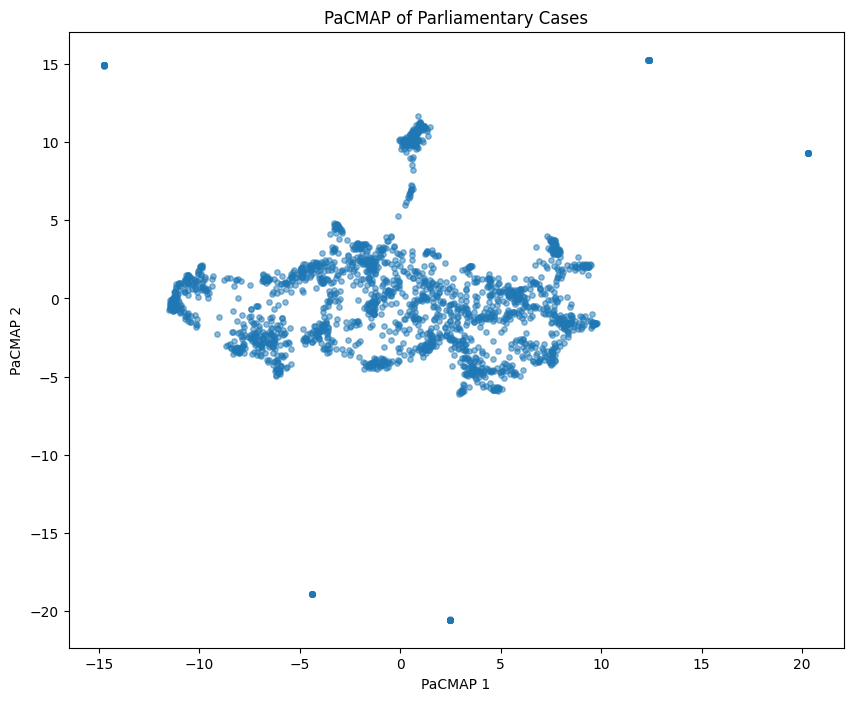

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(
    case_embeddings_pacmap[:, 0],
    case_embeddings_pacmap[:, 1],
    alpha=0.5,
    s=15
)

plt.xlabel("PaCMAP 1")
plt.ylabel("PaCMAP 2")
plt.title("PaCMAP of Parliamentary Cases")

plt.show()

### Test a range of k

We'll test k = 2 through 30 and calculate two diagnostics:

> Inertia — how tightly observations sit around their cluster centres. Useful for the elbow method.
>
>Silhouette score — compares how close a case is to its own cluster versus other clusters. Higher is better.

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 31)

inertias = []
silhouette_scores = []

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = kmeans.fit_predict(case_embeddings)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(case_embeddings, labels)
    )
    
    print(
        f"k={k:2d} | "
        f"inertia={kmeans.inertia_:8.2f} | "
        f"silhouette={silhouette_scores[-1]:.4f}"
    )

k= 2 | inertia=  310.69 | silhouette=0.0272
k= 3 | inertia=  304.67 | silhouette=0.0232
k= 4 | inertia=  300.21 | silhouette=0.0236
k= 5 | inertia=  296.43 | silhouette=0.0242
k= 6 | inertia=  293.21 | silhouette=0.0223
k= 7 | inertia=  290.48 | silhouette=0.0247
k= 8 | inertia=  287.62 | silhouette=0.0267
k= 9 | inertia=  285.14 | silhouette=0.0295
k=10 | inertia=  282.89 | silhouette=0.0291
k=11 | inertia=  280.48 | silhouette=0.0317
k=12 | inertia=  278.24 | silhouette=0.0321
k=13 | inertia=  276.58 | silhouette=0.0334
k=14 | inertia=  274.96 | silhouette=0.0344
k=15 | inertia=  272.21 | silhouette=0.0367
k=16 | inertia=  270.76 | silhouette=0.0367
k=17 | inertia=  269.86 | silhouette=0.0360
k=18 | inertia=  267.91 | silhouette=0.0366
k=19 | inertia=  266.37 | silhouette=0.0383
k=20 | inertia=  265.76 | silhouette=0.0406
k=21 | inertia=  264.72 | silhouette=0.0369
k=22 | inertia=  263.46 | silhouette=0.0408
k=23 | inertia=  262.18 | silhouette=0.0409
k=24 | inertia=  260.95 | silhou

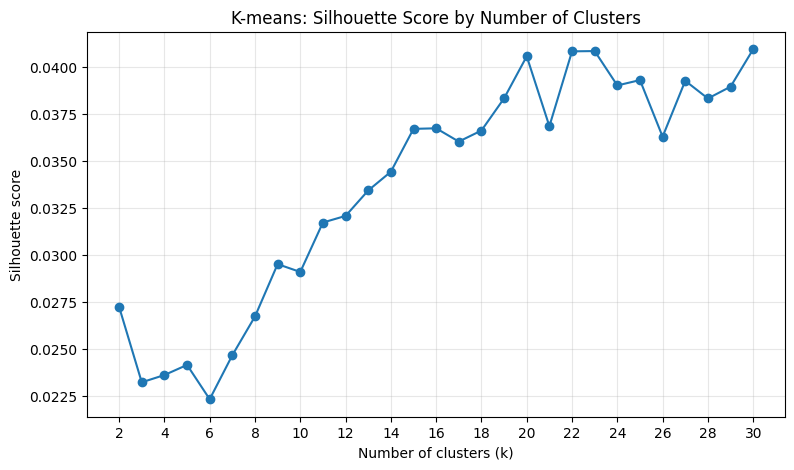

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-means: Silhouette Score by Number of Clusters")

plt.xticks(range(2, 31, 2))
plt.grid(alpha=0.3)

plt.show()

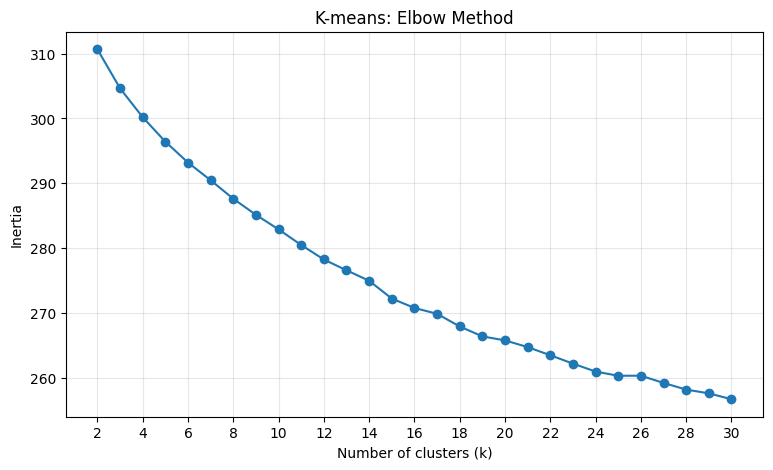

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-means: Elbow Method")

plt.xticks(range(2, 31, 2))
plt.grid(alpha=0.3)

plt.show()

In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=20,
    random_state=42,
    n_init=20
)

case_cluster_labels = kmeans.fit_predict(
    case_embeddings
)

df_cases["kmeans_cluster"] = case_cluster_labels

In [17]:
cluster_sizes = (
    df_cases["kmeans_cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_sizes)

kmeans_cluster
0      13
1     132
2      87
3      77
4     105
5     153
6     229
7     108
8      98
9     124
10    122
11     19
12    158
13    138
14    108
15    105
16     60
17    130
18    125
19     37
Name: count, dtype: int64


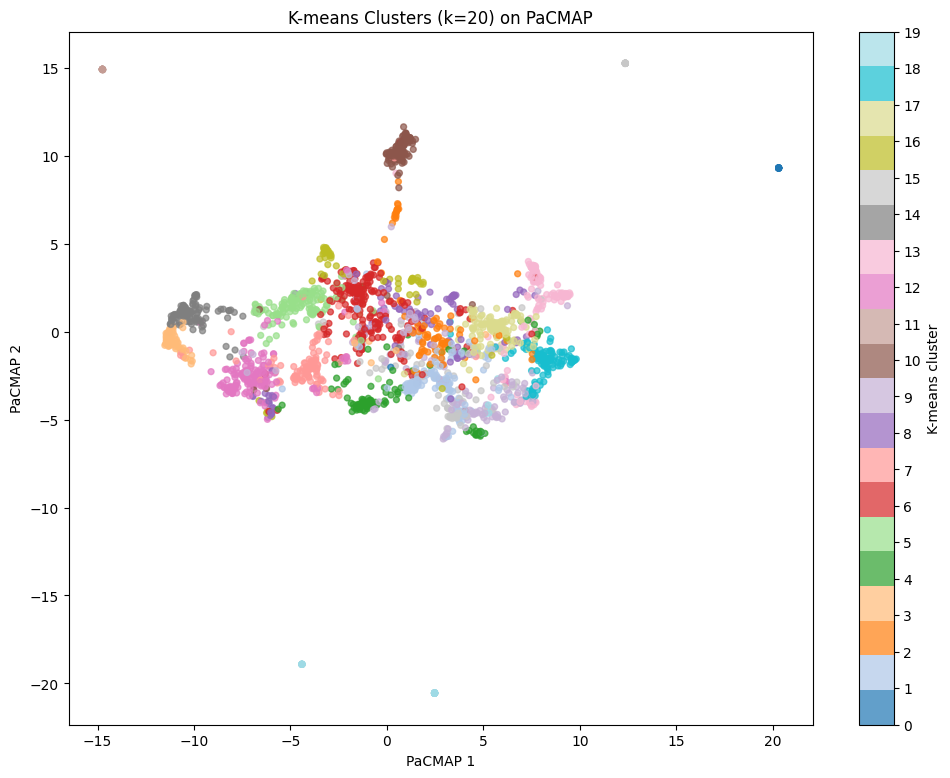

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))

scatter = plt.scatter(
    case_embeddings_pacmap[:, 0],
    case_embeddings_pacmap[:, 1],
    c=df_cases["kmeans_cluster"],
    cmap="tab20",
    s=18,
    alpha=0.7
)

plt.xlabel("PaCMAP 1")
plt.ylabel("PaCMAP 2")
plt.title("K-means Clusters (k=20) on PaCMAP")

plt.colorbar(
    scatter,
    label="K-means cluster",
    ticks=range(20)
)

plt.show()

### Now we find the most representative cases in each cluster

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

representative_cases = []

for cluster_id in range(20):

    cluster_mask = (
        df_cases["kmeans_cluster"] == cluster_id
    )

    cluster_embeddings = case_embeddings[cluster_mask]
    cluster_cases = df_cases[cluster_mask].copy()

    centroid = kmeans.cluster_centers_[cluster_id].reshape(1, -1)

    similarities = cosine_similarity(
        cluster_embeddings,
        centroid
    ).flatten()

    cluster_cases["centroid_similarity"] = similarities

    top_cases = (
        cluster_cases
        .sort_values(
            "centroid_similarity",
            ascending=False
        )
        .head(5)
    )

    representative_cases.append(top_cases)

In [20]:
for cluster_id, cases in enumerate(representative_cases):

    print(f"\n{'=' * 70}")
    print(
        f"CLUSTER {cluster_id} "
        f"(n={(df_cases['kmeans_cluster'] == cluster_id).sum()})"
    )
    print("=" * 70)

    for _, row in cases.iterrows():

        print(
            f"{row['centroid_similarity']:.3f} | "
            f"{row['sag_titel']}"
        )


CLUSTER 0 (n=13)
0.992 | Forslag til lov om tillægsbevilling for finansåret 2025.
0.991 | Forslag til lov om tillægsbevilling for finansåret 2023.
0.991 | Forslag til lov om tillægsbevilling for finansåret 2018.
0.991 | Forslag til lov om tillægsbevilling for finansåret 2024.
0.991 | Forslag til lov om tillægsbevilling for finansåret 2021.

CLUSTER 1 (n=132)
0.954 | Forslag til lov om ændring af lov om finansiel virksomhed, lov om investeringsforeninger m.v., lov om værdipapirhandel m.v. og forskellige andre love. (Forhøjelse af bødeniveauet for overtrædelse af lov om finansiel virksomhed, udpegning af systemisk vigtige finansielle institutter (SIFI), krav til egnethed og hæderlighed for nøglepersoner i SIFI'er, aflønningsregler for finansielle virksomheder m.v., lempelse af kapitalkrav for fondsmæglerselskaber, udvidelse af tilsyns- og kontrolbeføjelser for Finanstilsynet og Erhvervsstyrelsen for at imødegå markedsmisbrug m.v.).
0.954 | Forslag til lov om ændring af lov om finansiel 

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

k_values = [15, 20, 25, 30, 35, 40, 50]

k_results = []

for k in k_values:
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans_test.fit_predict(case_embeddings)

    silhouette = silhouette_score(
        case_embeddings,
        labels,
        metric="cosine"
    )

    cluster_sizes = pd.Series(labels).value_counts()

    k_results.append({
        "k": k,
        "silhouette": silhouette,
        "smallest_cluster": cluster_sizes.min(),
        "largest_cluster": cluster_sizes.max(),
        "median_cluster": cluster_sizes.median(),
        "clusters_under_10": (cluster_sizes < 10).sum(),
        "clusters_under_20": (cluster_sizes < 20).sum()
    })

df_k_results = pd.DataFrame(k_results)

df_k_results

,k,silhouette,smallest_cluster,largest_cluster,median_cluster,clusters_under_10,clusters_under_20
0,15,0.063937,20,277,147.0,0,0
1,20,0.069858,13,229,108.0,0,2
2,25,0.066912,15,144,97.0,0,2
3,30,0.070325,13,146,70.0,0,3
4,35,0.061855,12,129,64.0,0,4
5,40,0.069327,13,141,55.0,0,4
6,50,0.070225,1,103,42.5,2,7


In [22]:
from sklearn.cluster import KMeans

kmeans_30 = KMeans(
    n_clusters=30,
    random_state=42,
    n_init=20
)

df_cases["kmeans_cluster_30"] = kmeans_30.fit_predict(case_embeddings)

df_cases["kmeans_cluster_30"].value_counts().sort_index()

kmeans_cluster_30
0      42
1      75
2      20
3      36
4      58
5     100
6      84
7      58
8     112
9      63
10    110
11     19
12     16
13     55
14     71
15     69
16    125
17     72
18     81
19     27
20     66
21    106
22     46
23     91
24     94
25    146
26     63
27    111
28     13
29     99
Name: count, dtype: int64

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

representative_cases_30 = []

for cluster_id in range(30):

    cluster_mask = df_cases["kmeans_cluster_30"] == cluster_id

    cluster_embeddings = case_embeddings[cluster_mask]
    cluster_cases = df_cases[cluster_mask].copy()

    centroid = kmeans_30.cluster_centers_[cluster_id].reshape(1, -1)

    similarities = cosine_similarity(
        cluster_embeddings,
        centroid
    ).flatten()

    cluster_cases["centroid_similarity"] = similarities

    top_cases = (
        cluster_cases
        .sort_values("centroid_similarity", ascending=False)
        .head(3)
    )

    representative_cases_30.append(top_cases)

In [24]:
for cluster_id, top_cases in enumerate(representative_cases_30):

    n = (df_cases["kmeans_cluster_30"] == cluster_id).sum()

    print("=" * 70)
    print(f"CLUSTER {cluster_id} (n={n})")

    for _, row in top_cases.iterrows():
        print(f"- {row['sag_titel']}")

CLUSTER 0 (n=42)
- Forslag til lov om ændring af lov om etablering af en ordning for borgerforslag med henblik på behandling i Folketinget. (Ændring af revisionsbestemmelse og forenkling af kompetenceforhold med hensyn til udstedelse af bekendtgørelsesregler).
- Forslag til lov om ændring af lov om offentlighed i forvaltningen. (Ændring af revisionsbestemmelse).
- Forslag til lov om ændring af lov om offentlighed i forvaltningen. (Ændring af revisionsbestemmelse).
CLUSTER 1 (n=75)
- Forslag til lov om ændring af lov om almene boliger m.v., lov om friplejeboliger, lov om leje af almene boliger, lov om tvungen administration af udlejningsejendomme og lov om ejerlejligheder. (Medfinansiering af Center for Boligsocial Udvikling, mulighed for afskæring af klageadgang og ejerlejlighedsopdeling).
- Forslag til lov om boligforhold.
- Forslag til lov om ændring af lov om almene boliger m.v., lov om leje af almene boliger og lov om friplejeboliger. (Effektivisering af den almene boligsektors dri

In [27]:
import re
import pandas as pd

def normalize_title(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


df_cap_bills["title_normalized"] = (
    df_cap_bills["description"]
    .apply(normalize_title)
)

df_cases["title_normalized"] = (
    df_cases["sag_titel"]
    .apply(normalize_title)
)

In [28]:
print("CAP:")
display(
    df_cap_bills[
        ["year", "description", "title_normalized"]
    ].head()
)

print("ODA:")
display(
    df_cases[
        ["dato", "sag_titel", "title_normalized"]
    ].head()
)

CAP:


,year,description,title_normalized
0,1973,Forslag til lov om social bistand,forslag til lov om social bistand
1,1973,Lov om ændring af lov om registreringsafgift,lov om ændring af lov om registreringsafgift
2,1973,Forslag til lov om ændring af lov om pension o...,forslag til lov om ændring af lov om pension o...
3,1973,Forslag til lov om ændring af lov om folkepens...,forslag til lov om ændring af lov om folkepens...
4,1973,Forslag til lov om ændring af lov om om omsorg...,forslag til lov om ændring af lov om om omsorg...


ODA:


,dato,sag_titel,title_normalized
0,2014-09-09 09:15:00,Forslag til lov om ændring af virksomhedsskatt...,forslag til lov om ændring af virksomhedsskatt...
1,2014-10-31 10:00:00,Forslag til lov om ændring af lov om afgift af...,forslag til lov om ændring af lov om afgift af...
2,2014-12-02 13:00:00,Forslag til lov om ændring af lov om produktio...,forslag til lov om ændring af lov om produktio...
3,2014-12-02 13:00:00,Forslag til lov om dansk turisme.,forslag til lov om dansk turisme
4,2014-12-04 10:00:00,Forslag til lov om ændring af lov om aktiv soc...,forslag til lov om ændring af lov om aktiv soc...


In [29]:
df_cases["calendar_year"] = (
    pd.to_datetime(df_cases["dato"])
    .dt.year
)


In [30]:
print(
    "CAP calendar years:",
    df_cap_bills["calendar_year"].min(),
    "-",
    df_cap_bills["calendar_year"].max()
)

print(
    "ODA calendar years:",
    df_cases["calendar_year"].min(),
    "-",
    df_cases["calendar_year"].max()
)

CAP calendar years: 1953.0 - 2017.0
ODA calendar years: 2014 - 2026


In [32]:
df_cap_bills["calendar_year"] = (
    pd.to_numeric(df_cap_bills["calendar_year"], errors="coerce")
    .astype("Int64")
)

df_cases["calendar_year"] = (
    pd.to_datetime(df_cases["dato"])
    .dt.year
    .astype("Int64")
)

In [33]:
df_cap_oda = df_cases.merge(
    df_cap_bills[
        [
            "title_normalized",
            "calendar_year",
            "majortopic",
            "subtopic",
            "description"
        ]
    ],
    on=["title_normalized", "calendar_year"],
    how="inner"
)

In [34]:
print("Matched rows:", len(df_cap_oda))
print("Unique ODA cases:", df_cap_oda["sagid"].nunique())
print("Unique CAP topics:", df_cap_oda["majortopic"].nunique())

Matched rows: 555
Unique ODA cases: 533
Unique CAP topics: 21


In [35]:
matches_per_case = (
    df_cap_oda
    .groupby("sagid")
    .size()
    .value_counts()
    .sort_index()
)

print(matches_per_case)

1    514
2     16
3      3
Name: count, dtype: int64


In [37]:
df_cap_labels = (
    df_cap_oda[
        [
            "sagid",
            "sag_nummer",
            "sag_titel",
            "dato",
            "majortopic",
            "subtopic"
        ]
    ]
    .drop_duplicates(subset="sagid")
    .reset_index(drop=True)
)

print(df_cap_labels.shape)
df_cap_labels.head()

(533, 6)


,sagid,sag_nummer,sag_titel,dato,majortopic,subtopic
0,1449,L 200,Forslag til lov om ændring af virksomhedsskatt...,2014-09-09 09:15:00,1,107
1,12715,L 4,Forslag til lov om ændring af lov om afgift af...,2014-10-31 10:00:00,1,107
2,13015,L 33,Forslag til lov om ændring af lov om produktio...,2014-12-02 13:00:00,6,602
3,13004,L 19,Forslag til lov om dansk turisme.,2014-12-02 13:00:00,15,1524
4,12991,L 13,Forslag til lov om ændring af lov om aktiv soc...,2014-12-04 10:00:00,13,1302


In [39]:
df_cluster_cap_30 = df_cases[
    ["sagid", "sag_titel", "kmeans_cluster_30"]
].merge(
    df_cap_labels[
        ["sagid", "majortopic", "subtopic"]
    ],
    on="sagid",
    how="inner"
)

print("Matched cases:", len(df_cluster_cap_30))
print("Unique cases:", df_cluster_cap_30["sagid"].nunique())

Matched cases: 533
Unique cases: 533


In [40]:
cluster_cap_counts_30 = pd.crosstab(
    df_cluster_cap_30["kmeans_cluster_30"],
    df_cluster_cap_30["majortopic"]
)

cluster_cap_props_30 = pd.crosstab(
    df_cluster_cap_30["kmeans_cluster_30"],
    df_cluster_cap_30["majortopic"],
    normalize="index"
)

cluster_summary_30 = pd.DataFrame({
    "n_cluster": (
        df_cases["kmeans_cluster_30"]
        .value_counts()
        .sort_index()
    ),
    "n_cap_labeled": cluster_cap_counts_30.sum(axis=1),
    "dominant_cap": cluster_cap_counts_30.idxmax(axis=1),
    "dominant_share": cluster_cap_props_30.max(axis=1)
})

cluster_summary_30

,n_cluster,n_cap_labeled,dominant_cap,dominant_share
kmeans_cluster_30,,,,
0,42,8.0,2.0,0.500000
1,75,21.0,14.0,0.619048
2,20,8.0,9.0,1.000000
3,36,9.0,1.0,1.000000
4,58,35.0,5.0,0.657143
5,100,10.0,20.0,0.300000
6,84,30.0,13.0,0.366667
7,58,12.0,15.0,0.666667
8,112,22.0,12.0,0.818182


In [41]:
for cluster_id in range(30):

    if cluster_id not in cluster_cap_counts_30.index:
        print(f"\nCluster {cluster_id}: no CAP-labelled cases")
        continue

    counts = (
        cluster_cap_counts_30
        .loc[cluster_id]
    )

    counts = counts[counts > 0].sort_values(ascending=False)

    total = counts.sum()

    print(f"\nCLUSTER {cluster_id} (CAP-labelled n={total})")

    for topic, count in counts.items():
        share = count / total
        print(
            f"  CAP {int(topic):2d}: "
            f"{count:2d} cases "
            f"({share:.1%})"
        )


CLUSTER 0 (CAP-labelled n=8)
  CAP  2:  4 cases (50.0%)
  CAP 20:  2 cases (25.0%)
  CAP  6:  1 cases (12.5%)
  CAP 15:  1 cases (12.5%)

CLUSTER 1 (CAP-labelled n=21)
  CAP 14: 13 cases (61.9%)
  CAP  6:  1 cases (4.8%)
  CAP  8:  1 cases (4.8%)
  CAP 12:  1 cases (4.8%)
  CAP  9:  1 cases (4.8%)
  CAP 13:  1 cases (4.8%)
  CAP 15:  1 cases (4.8%)
  CAP 17:  1 cases (4.8%)
  CAP 21:  1 cases (4.8%)

CLUSTER 2 (CAP-labelled n=8)
  CAP  9:  8 cases (100.0%)

CLUSTER 3 (CAP-labelled n=9)
  CAP  1:  9 cases (100.0%)

CLUSTER 4 (CAP-labelled n=35)
  CAP  5: 23 cases (65.7%)
  CAP 13:  5 cases (14.3%)
  CAP 15:  4 cases (11.4%)
  CAP 20:  2 cases (5.7%)
  CAP 16:  1 cases (2.9%)

CLUSTER 5 (CAP-labelled n=10)
  CAP 20:  3 cases (30.0%)
  CAP 12:  2 cases (20.0%)
  CAP 14:  2 cases (20.0%)
  CAP  1:  1 cases (10.0%)
  CAP 13:  1 cases (10.0%)
  CAP 15:  1 cases (10.0%)

CLUSTER 6 (CAP-labelled n=30)
  CAP 13: 11 cases (36.7%)
  CAP 12:  8 cases (26.7%)
  CAP  3:  5 cases (16.7%)
  CAP 20:  

In [42]:
clusters_to_inspect = [5, 6, 9, 13, 15, 16, 18, 24, 26, 29]

In [43]:
for cluster_id in clusters_to_inspect:

    sample = (
        df_cases[
            df_cases["kmeans_cluster_30"] == cluster_id
        ]
        .sample(
            n=min(
                10,
                (df_cases["kmeans_cluster_30"] == cluster_id).sum()
            ),
            random_state=42
        )
    )

    print("=" * 80)
    print(f"CLUSTER {cluster_id}")

    for title in sample["sag_titel"]:
        print(f"- {title}")

CLUSTER 5
- Forslag til lov om ændring af retsplejeloven, lov om skifte af dødsboer og arveloven. (Revision af reglerne om Advokatsamfundets organer, udvidelse af adgangen til at opnå møderet for landsret, værgers betaling af sagsomkostninger og digital behandling af sager om skifte af dødsboer).
- Forslag til lov om ændring af lov om et midlertidigt børnetilskud til visse forsørgere. (Forlængelse af det midlertidige børnetilskud for 2023).
- Forslag til lov om ændring af barselsloven. (13 ugers ekstra orlov til begge tvillingeforældre m.v.).
- Forslag til lov om ændring af barselsloven. (Indførelse af øremærket orlov, ligedeling af retten til barselsdagpenge og ret til overdragelse af barselsdagpenge til sociale forældre og nærtstående familiemedlemmer m.v.).
- Forslag til lov om ændring af børneloven, navneloven og forskellige andre love. (Smidiggørelse af registrering af medmoderskab, fastsættelse af transpersoners forældreskab og navneændring for transpersoner m.v.).
- Forslag til 

In [44]:
kmeans_40 = KMeans(
    n_clusters=40,
    random_state=42,
    n_init=20
)

df_cases["kmeans_cluster_40"] = kmeans_40.fit_predict(
    case_embeddings
)

In [45]:
problem_clusters = [0, 5, 9, 15, 16, 18]

for cluster_id in problem_clusters:

    subset = df_cases[
        df_cases["kmeans_cluster_30"] == cluster_id
    ]

    print(f"\nk=30 CLUSTER {cluster_id} (n={len(subset)})")

    print(
        subset["kmeans_cluster_40"]
        .value_counts()
        .sort_values(ascending=False)
    )


k=30 CLUSTER 0 (n=42)
kmeans_cluster_40
20    17
17    12
10     3
14     3
23     2
25     1
16     1
1      1
32     1
35     1
Name: count, dtype: int64

k=30 CLUSTER 5 (n=100)
kmeans_cluster_40
27    22
35    20
38    13
26    12
16    10
17     3
24     3
11     3
8      2
12     2
32     2
33     2
1      1
9      1
25     1
5      1
14     1
7      1
Name: count, dtype: int64

k=30 CLUSTER 9 (n=63)
kmeans_cluster_40
21    46
7      3
26     3
3      2
19     2
36     1
12     1
23     1
31     1
16     1
22     1
24     1
Name: count, dtype: int64

k=30 CLUSTER 15 (n=69)
kmeans_cluster_40
30    33
23    20
24     8
3      7
0      1
Name: count, dtype: int64

k=30 CLUSTER 16 (n=125)
kmeans_cluster_40
17    50
11    29
37    13
1      9
27     5
7      3
16     2
23     2
24     2
32     2
18     2
21     1
22     1
3      1
26     1
0      1
2      1
Name: count, dtype: int64

k=30 CLUSTER 18 (n=81)
kmeans_cluster_40
37    55
24     7
4      4
28     4
17     3
3      2
13     

In [46]:
clusters_40_to_inspect = [
    11, 17,       # main split of old cluster 16
    23, 30,       # main split of old cluster 15
    16, 26, 27, 35, 38,  # old cluster 5
    21,           # old cluster 9
    37            # old clusters 16/18
]

for cluster_id in clusters_40_to_inspect:

    subset = df_cases[
        df_cases["kmeans_cluster_40"] == cluster_id
    ]

    sample = subset.sample(
        n=min(8, len(subset)),
        random_state=42
    )

    print("=" * 80)
    print(f"k=40 CLUSTER {cluster_id} (total n={len(subset)})")

    for title in sample["sag_titel"]:
        print(f"- {title}")

k=40 CLUSTER 11 (total n=141)
- Forslag til lov om ændring af straffeloven, retsplejeloven og udlændingeloven. (Skærpet straf for lovovertrædelser med baggrund i eller sammenhæng med covid-19 og blokering af hjemmesider, hvorfra der begås visse lovovertrædelser, som har baggrund i eller sammenhæng med covid-19).
- Forslag til lov for Færøerne om fuldbyrdelse af straf m.v.
- Forslag til lov om ændring af straffeloven, lov om forældelse af fordringer, lov om erstatningsansvar og lov om erstatning fra staten til ofre for forbrydelser. (Ophævelse af forældelsesfrister for gerningsmandens strafansvar i sager om seksuelt misbrug af børn og for erstatningskrav mod forvaltningsmyndigheder for svigt i sager om overgreb mod børn, forhøjelse af niveauet for tortgodtgørelse for seksuelle krænkelser samt ophævelse af 72-timersreglen i sager om voldtægt, incest og seksuelt misbrug af børn m.v.).
- Forslag til lov om ændring af retsplejeloven. (Tilfældighedsfund som bevis i sager om opløsning af en f